In [61]:
# MLP approach 

In [62]:
# Imports 
import matplotlib.pyplot as plt
import matplotlib as mp
%matplotlib widget 
import numpy as np
import mne
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Normalization
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Functions

In [63]:

def rereferencingEpoching(raw, onset_number, error_number,channel_exclude_list, reref_channels, apply_filter): 
    # rereferencing 
    rereferenced_eeg_raw = raw.copy()
    rereferenced_eeg_raw = rereferenced_eeg_raw.drop_channels(['x_dir', 'y_dir', 'z_dir'])
    
    if not (reref_channels):
        print("no reref channels specified, using original ref")
        print("")
    else: 
        if (reref_channels[0] == "average"):
            print("using average reference over all electrodes")
            print("")
            rereferenced_eeg_raw, ref_data = mne.set_eeg_reference(rereferenced_eeg_raw, ref_channels='average' ,copy=True)
        else:
            print("using custom electrodes for rereferencing")
            print("")
            rereferenced_EEG_raw, ref_data = mne.set_eeg_reference(rereferenced_eeg_raw, ref_channels=reref_channels ,copy=True)
    

    raw_eeg_rereferenced = rereferenced_eeg_raw.copy()
    #drop channel

    #apply filter 
    if (apply_filter): 
        filtered_eeg_rereferenced = raw_eeg_rereferenced.filter(f_highpass,f_lowpass)
    else: 
        filtered_eeg_rereferenced = raw_eeg_rereferenced
    
    #extract events 
    plot_events, plot_event_dict = mne.events_from_annotations(filtered_eeg_rereferenced)
    plot_onset_indices = np.where(plot_events[:,2] == onset_number)[0] # S100 marker is leaving plate 
    exclude_indices = np.where(plot_events[:,2] == error_number)[0] # S3 marker should be excluded 

    plot_onset_indices = plot_onset_indices[0:-1] # cut of last movement, might be after experiment
    include_mask = np.ones(plot_onset_indices.shape)

    #search for correct indizes without S3 errors 
    for i in range(0, len(plot_onset_indices)): 
        for j in range(0, len(exclude_indices)):
            if ((exclude_indices[j]-1) == plot_onset_indices[i] or (exclude_indices[j]-2) == plot_onset_indices[i]):
                include_mask[i] = 0

    #Epochs with an S3 error are excluded 
    plot_onset_indices_correct = plot_onset_indices[include_mask.astype(bool)]

    #create new event matrix 
    used_plot_events = np.zeros((len(plot_onset_indices_correct),3))
    used_plot_events = plot_events[plot_onset_indices_correct,:]

    #eeg_epochs = mne.Epochs(filtered_eeg_rereferenced, events = used_plot_events, event_id = event_id_used,tmin=t1, baseline=None, tmax=t2, preload=True, reject_by_annotation = True)
    if not(channel_exclude_list): 
        if(apply_baseline_correction): 
            eeg_epochs = mne.Epochs(filtered_eeg_rereferenced, events = used_plot_events, event_id = event_id_used, tmin=t1, baseline=(-1.5, -1), tmax=t2, preload=True, reject_by_annotation = True)
        else: 
            eeg_epochs = mne.Epochs(filtered_eeg_rereferenced, events = used_plot_events, event_id = event_id_used, tmin=t1, baseline=None, tmax=t2, preload=True, reject_by_annotation = True)
            
    else: #drop specified channels if given 
        filtered_eeg_rereferenced.drop_channels(channel_exclude_list)
        if(apply_baseline_correction): 
            eeg_epochs = mne.Epochs(filtered_eeg_rereferenced, events = used_plot_events, event_id = event_id_used,tmin=t1, tmax=t2, baseline=(-1.5, -1), preload=True, reject_by_annotation = True)
        else: 
            eeg_epochs = mne.Epochs(filtered_eeg_rereferenced, events = used_plot_events, event_id = event_id_used,tmin=t1, tmax=t2, baseline=None, preload=True, reject_by_annotation = True)
    
    # Get remaining channel names  
    remaining_eeg_channel_names = filtered_eeg_rereferenced.ch_names
    
    lrp_epoch_obj = eeg_epochs.copy() # the object of epochs from mne 

    #get data out as numpy array for further processing 
    lrp_epochs = eeg_epochs.get_data() 
    
    #generate a time axis for the epochs 
    time_axis_eeg_batch = np.arange(t1,t2+1/f_samp_eeg, step = 1/f_samp_eeg) #build time axis (epoch)

    #return everything needed for further processing 
    return lrp_epochs, lrp_epoch_obj, time_axis_eeg_batch, remaining_eeg_channel_names, filtered_eeg_rereferenced # shape of epochs: (epochs, channel, samples)


def calcTestAccAndRates(prediction_labels, true_labels):
    prediction_labels = prediction_labels.astype(int)
    true_labels = true_labels.astype(int)
    
    negatives = np.sum(np.abs(true_labels-1))
    positives = np.sum(true_labels)
    
    n = len(true_labels)
    tps= 0 
    tns = 0
    for index in range(0, n): 
        if (prediction_labels[index] == 0 and true_labels[index] == 0):
            tns = tns+1
        elif (prediction_labels[index] == 1 and true_labels[index] == 1): 
            tps = tps+1
    tnr = tns/negatives
    tpr = tps/positives
    acc = ((tns+tps)/n) #in percent
    return tnr, tpr, acc
    

# Dataset selection and user parameters

In [64]:
# Data Strings Study 
# Give the path of the datasets to be evaluated 
data_str_uni_JV43_set1 = 'data/20211210_r_JV43_intentional_unilateral_set1.vhdr'
data_str_uni_JV43_set2 = 'data/20211210_r_JV43_intentional_unilateral_set2.vhdr'
data_str_uni_JV43_set3 = 'data/20211210_r_JV43_intentional_unilateral_set3.vhdr'

# A list of dataset strings to be evaluated 
dataset_list = [data_str_uni_JV43_set1, data_str_uni_JV43_set2, data_str_uni_JV43_set3]

#EEG Reading Parameter 
# Channelnumbers with EEG Data from Dataset

eeg_channel_start_number = 0 
eeg_channel_end_number   = 67 # 64 eeg and 3 axis accelerometer (automatically removed laterl on )

# Filtering Params 
f_highpass = 0.1 # in Hz 
f_lowpass = 4.0 # in Hz 
apply_filter = True

#rereferencing (["average"] or [] (no reref))
reref_channel = []

# should baseline correction be applied ? (standard -1.5 to -1 seconds)
apply_baseline_correction = False

# Plotting Specs 
plots_color = 'black'
text_sizes = 10 
figure_sizes = (8,4)

f_samp_eeg = 500 #sample Frequency
marker_number = 100 # onset markernumber (Qualisys)
onset_number = marker_number
error_number = 3 # number of the error marker 

# specifying the movement onset marker 
event_id_used = {"movement_onset": marker_number} 
# epoche times 

epoching_time_before_onset = -5.0
epoching_time_after_onset = 0 # remains 0 (movement onset)

#machine learning params 
# one second from resting and movement preparation: 
# therefore 500 sampels (one second) are used as features for both classes starting at
# "epoching_time_before_onset" for neg and "epoching_time_after_onset-fsamp_features" for pos class
n_samp_features = 500 
chosen_test_size = 0.2 # test size of the data 
input_dim = 34
first_layer_units = 34
second_layer_units = 8 
n_epochs = 200 
n_batch_size = 256
validation_rate = 0.2 # use 20% as validation data 

t1 = epoching_time_before_onset
t2 = epoching_time_after_onset

# eeg channel that are excluded from the evaluation 
channel_exclude_list = ['FP1', 'FP2', 'F8', 'T7', 'T8', 'TP9', 'TP10', 'P7','P8', 'PO9', 'O1', 'OZ', 'O2', 'PO10', 'AF7', 'AF3', 'AF4', 'AF8', 'FT9', 'FT7', 'FT8', 'FT10', 'TP7', 'TP8', 'PO7', 'PO3', 'POZ', 'PO4', 'PO8','F7']


# Load and merge EEG datasets

In [65]:

# append all datasets together to one giant list with raw instances 
raw_list = []
for dataset in dataset_list: 
    raw1 = mne.io.read_raw_brainvision(dataset, preload = True, verbose = False)
    raw_list.append(raw1)
    
# concetenate all raw files to one dataset 
raw = mne.concatenate_raws(raw_list)


<ipython-input-65-09caade55c9f>:4: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw1 = mne.io.read_raw_brainvision(dataset, preload = True, verbose = False)
<ipython-input-65-09caade55c9f>:4: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw1 = mne.io.read_raw_brainvision(dataset, preload = True, verbose = False)
<ipython-input-65-09caade55c9f>:4: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw1 = mne.io.read_raw_brainvision(dataset, preload = True, verbose = False)


# EEG Preprocessing and epoching

In [66]:
#channel_exclude_list = ['FP1', 'FP2', 'F8', 'T7', 'T8', 'TP9', 'TP10', 'P7','P8', 'PO9', 'O1', 'OZ', 'O2', 'PO10', 'AF7', 'AF3', 'AF4', 'AF8', 'FT9', 'FT7', 'FT8', 'FT10', 'TP7', 'TP8', 'PO7', 'PO3', 'POZ', 'PO4', 'PO8','F7']
#channel_exclude_list = []

lrp_epochs, lrp_epochs_obj, time_axis_eeg_batch, remaining_eeg_channel_names, filtered_eeg_rereferenced = rereferencingEpoching(raw, onset_number, error_number, channel_exclude_list, reref_channel, apply_filter)
mean_lrp_epochs = np.mean(lrp_epochs, axis = 0) #average over epochs 

print("")
print("Shape of Epochs: ", lrp_epochs.shape)
print("Shape is in form: (trials, channel, sampels)")
print("Remaining EEG-channel names", remaining_eeg_channel_names)


no reref channels specified, using original ref

Used Annotations descriptions: ['Comment/EndPrealloc', 'Comment/StartPrealloc', 'New Segment/', 'New Segment/LostSamples: 4000', 'Stimulus/S  1', 'Stimulus/S  8', 'Stimulus/S  9', 'Stimulus/S 20', 'Stimulus/S 21', 'Stimulus/S 22', 'Stimulus/S 23', 'Stimulus/S 27', 'Stimulus/S 99', 'Stimulus/S100', 'Stimulus/S128']
Not setting metadata
Not setting metadata
122 matching events found
No baseline correction applied
0 projection items activated
Loading data for 122 events and 2501 original time points ...
0 bad epochs dropped

Shape of Epochs:  (122, 34, 2501)
Shape is in form: (trials, channel, sampels)
Remaining EEG-channel names ['F3', 'FZ', 'F4', 'FC5', 'FC1', 'FC2', 'FC6', 'C3', 'CZ', 'C4', 'CP5', 'CP1', 'CP2', 'CP6', 'P3', 'PZ', 'P4', 'F5', 'F1', 'F2', 'F6', 'FC3', 'FC4', 'C5', 'C1', 'C2', 'C6', 'CP3', 'CPZ', 'CP4', 'P5', 'P1', 'P2', 'P6']


Text(0, 0.5, 'Amplitude in V')

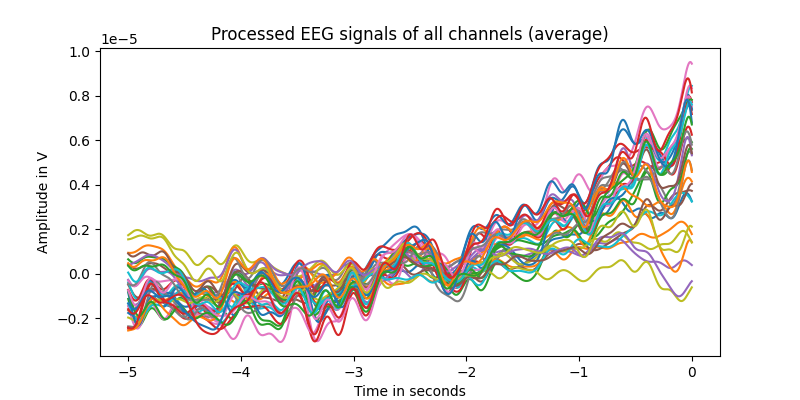

In [67]:
# show the data 
plt.figure(figsize = figure_sizes)
plt.title("Processed EEG signals of all channels (average)")
plt.plot(time_axis_eeg_batch, (mean_lrp_epochs.T))
plt.xlabel('Time in seconds')
plt.ylabel('Amplitude in V')

# Prepare data for network

In [68]:
# preparing data 
tensor_shape = lrp_epochs.shape # shape is (trials, channel, sampels)

n_start = n_samp_features # number of samples to use as features 
n_end = 1
lrp_idx_1 = tensor_shape[2]-n_start-1
lrp_idx_2 = tensor_shape[2]-n_end
no_lrp_idx_1 = n_start

print("lrp indizes are: ", lrp_idx_1, lrp_idx_2)
print("no_lrp indizes are: ", 0, no_lrp_idx_1)

#seperate the samples of both classes 
lrp_sampels = lrp_epochs[:, :, lrp_idx_1:lrp_idx_2] # shape (trials, channel, sampels)
no_lrp_sampels = lrp_epochs[:, :, 0:no_lrp_idx_1]

#output the time values of the cutted slices: 
lrp_times = np.array([time_axis_eeg_batch[lrp_idx_1] *1000,time_axis_eeg_batch[lrp_idx_2]*1000])
no_lrp_times = np.array([time_axis_eeg_batch[0]*1000,time_axis_eeg_batch[no_lrp_idx_1]*1000])

print("lrp times in ms: ", (lrp_times).astype(dtype=np.int32))
print("no_lrp times in ms: ", (no_lrp_times.astype(dtype=np.int32)))

# init arrays for both classes 
lrp_shaped = np.zeros((lrp_sampels.shape[0]*lrp_sampels.shape[2], lrp_sampels.shape[1]))
no_lrp_shaped = np.zeros((no_lrp_sampels.shape[0]*no_lrp_sampels.shape[2], no_lrp_sampels.shape[1]))

# flatten sampels and trials to one dim 
for channel in range(0, tensor_shape[1]): 
    lrp_shaped[:, channel] = lrp_sampels[:,channel,:].flatten()
    no_lrp_shaped[:, channel] = no_lrp_sampels[:,channel,:].flatten()

#merge data together 
x_merged = np.concatenate((lrp_shaped, no_lrp_shaped), axis=0).astype(dtype = np.float32)

#create label encoding 
y = np.zeros((x_merged.shape[0],1)).astype(dtype=np.float32)
y[0:lrp_shaped.shape[0]] = 1.0

#norm channel wise 
normalizer = Normalization(axis=-1)
normalizer.adapt(x_merged)
x_norm = normalizer(x_merged)
x_norm = np.array(x_norm)

x_prepared = np.concatenate((x_norm, y), axis = 1)
#x_save = X_prepared.copy()

# shuffle 
np.random.shuffle(x_prepared) # shuffle the data 

#seperate data and label after shuffling 
x = x_prepared[:,0:len(remaining_eeg_channel_names)] #shape (data, channel)
y = x_prepared[:,len(remaining_eeg_channel_names)] # shape (label, )

#seperate to train, validation and test 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=chosen_test_size)
print("Shape of train data: ", x_train.shape)

lrp indizes are:  2000 2500
no_lrp indizes are:  0 500
lrp times in ms:  [-1000     0]
no_lrp times in ms:  [-5000 -4000]
Shape of train data:  (97600, 34)


In [69]:
# Use some example trial (before machine learning) to check results on single trial afterwards 
trial_num = 10
example_lrp_trial = lrp_sampels[trial_num, :, :].T
example_no_lrp_trial = no_lrp_sampels[trial_num, :, :].T
example_lrp_trial_norm = normalizer(example_lrp_trial)
example_no_lrp_trial_norm = normalizer(example_no_lrp_trial)


# Build ML Model in keras

In [70]:
# MLP setup 
model = Sequential()
model.add(Dense(units=first_layer_units, activation='relu', input_dim=input_dim))
model.add(Dense(units=second_layer_units, activation='relu'))
model.add(Dense(units=1, activation='sigmoid')) 


In [71]:
#show model 
print(model.summary())

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_12 (Dense)             (None, 34)                1190      
_________________________________________________________________
dense_13 (Dense)             (None, 8)                 280       
_________________________________________________________________
dense_14 (Dense)             (None, 1)                 9         
Total params: 1,479
Trainable params: 1,479
Non-trainable params: 0
_________________________________________________________________
None


In [72]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics='accuracy')
history = model.fit(x_train, 
                    y_train, 
                    epochs  = n_epochs, 
                    batch_size= n_batch_size, 
                    validation_split = validation_rate)
                    

Epoch 1/200
305/305 [==============================] - 0s 760us/step - loss: 0.4215 - accuracy: 0.8052 - val_loss: 0.3198 - val_accuracy: 0.8643
Epoch 2/200
305/305 [==============================] - 0s 568us/step - loss: 0.2823 - accuracy: 0.8789 - val_loss: 0.2563 - val_accuracy: 0.8902
Epoch 3/200
305/305 [==============================] - 0s 558us/step - loss: 0.2348 - accuracy: 0.9011 - val_loss: 0.2214 - val_accuracy: 0.9076
Epoch 4/200
305/305 [==============================] - 0s 563us/step - loss: 0.2064 - accuracy: 0.9140 - val_loss: 0.1977 - val_accuracy: 0.9178
Epoch 5/200
305/305 [==============================] - 0s 576us/step - loss: 0.1855 - accuracy: 0.9243 - val_loss: 0.1818 - val_accuracy: 0.9291
Epoch 6/200
305/305 [==============================] - 0s 567us/step - loss: 0.1694 - accuracy: 0.9323 - val_loss: 0.1655 - val_accuracy: 0.9348
Epoch 7/200
305/305 [==============================] - 0s 567us/step - loss: 0.1561 - accuracy: 0.9383 - val_loss: 0.1525 - val_ac

305/305 [==============================] - 0s 556us/step - loss: 0.0133 - accuracy: 0.9968 - val_loss: 0.0114 - val_accuracy: 0.9972
Epoch 58/200
305/305 [==============================] - 0s 554us/step - loss: 0.0100 - accuracy: 0.9980 - val_loss: 0.0150 - val_accuracy: 0.9953
Epoch 59/200
305/305 [==============================] - 0s 559us/step - loss: 0.0114 - accuracy: 0.9973 - val_loss: 0.0283 - val_accuracy: 0.9899
Epoch 60/200
305/305 [==============================] - 0s 565us/step - loss: 0.0105 - accuracy: 0.9977 - val_loss: 0.0106 - val_accuracy: 0.9976
Epoch 61/200
305/305 [==============================] - 0s 559us/step - loss: 0.0090 - accuracy: 0.9983 - val_loss: 0.0099 - val_accuracy: 0.9975
Epoch 62/200
305/305 [==============================] - 0s 558us/step - loss: 0.0094 - accuracy: 0.9981 - val_loss: 0.0114 - val_accuracy: 0.9970
Epoch 63/200
305/305 [==============================] - 0s 559us/step - loss: 0.0079 - accuracy: 0.9987 - val_loss: 0.0078 - val_accuracy

305/305 [==============================] - 0s 562us/step - loss: 0.0012 - accuracy: 1.0000 - val_loss: 0.0014 - val_accuracy: 0.9999
Epoch 114/200
305/305 [==============================] - 0s 554us/step - loss: 0.0011 - accuracy: 1.0000 - val_loss: 0.0014 - val_accuracy: 0.9999
Epoch 115/200
305/305 [==============================] - 0s 557us/step - loss: 0.0216 - accuracy: 0.9948 - val_loss: 0.0050 - val_accuracy: 0.9990
Epoch 116/200
305/305 [==============================] - 0s 565us/step - loss: 0.0021 - accuracy: 0.9998 - val_loss: 0.0020 - val_accuracy: 0.9998
Epoch 117/200
305/305 [==============================] - 0s 556us/step - loss: 0.0013 - accuracy: 0.9999 - val_loss: 0.0016 - val_accuracy: 0.9999
Epoch 118/200
305/305 [==============================] - 0s 556us/step - loss: 0.0012 - accuracy: 1.0000 - val_loss: 0.0015 - val_accuracy: 0.9999
Epoch 119/200
305/305 [==============================] - 0s 552us/step - loss: 0.0011 - accuracy: 1.0000 - val_loss: 0.0016 - val_ac

305/305 [==============================] - 0s 559us/step - loss: 5.6020e-04 - accuracy: 1.0000 - val_loss: 7.3670e-04 - val_accuracy: 0.9999
Epoch 168/200
305/305 [==============================] - 0s 571us/step - loss: 5.3054e-04 - accuracy: 1.0000 - val_loss: 6.5436e-04 - val_accuracy: 1.0000
Epoch 169/200
305/305 [==============================] - 0s 570us/step - loss: 4.9577e-04 - accuracy: 1.0000 - val_loss: 5.9106e-04 - val_accuracy: 1.0000
Epoch 170/200
305/305 [==============================] - 0s 554us/step - loss: 5.8470e-04 - accuracy: 1.0000 - val_loss: 6.1124e-04 - val_accuracy: 1.0000
Epoch 171/200
305/305 [==============================] - 0s 561us/step - loss: 4.7581e-04 - accuracy: 1.0000 - val_loss: 5.8769e-04 - val_accuracy: 1.0000
Epoch 172/200
305/305 [==============================] - 0s 549us/step - loss: 4.4292e-04 - accuracy: 1.0000 - val_loss: 5.5229e-04 - val_accuracy: 1.0000
Epoch 173/200
305/305 [==============================] - 0s 551us/step - loss: 0.009

# Show training results 

Text(0.5, 1.0, 'Accuracy over trained epochs')

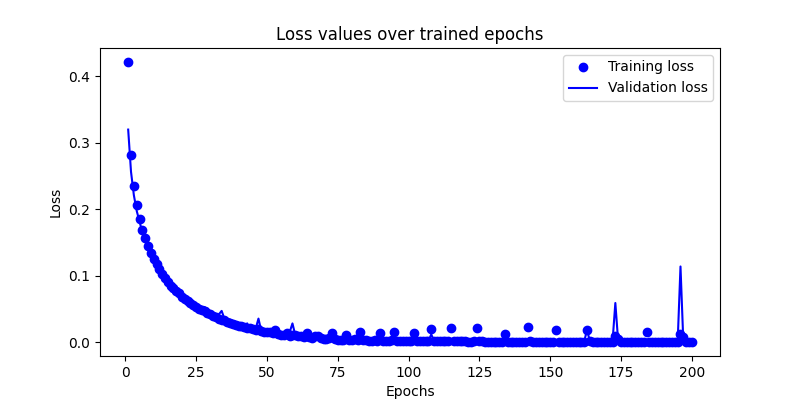

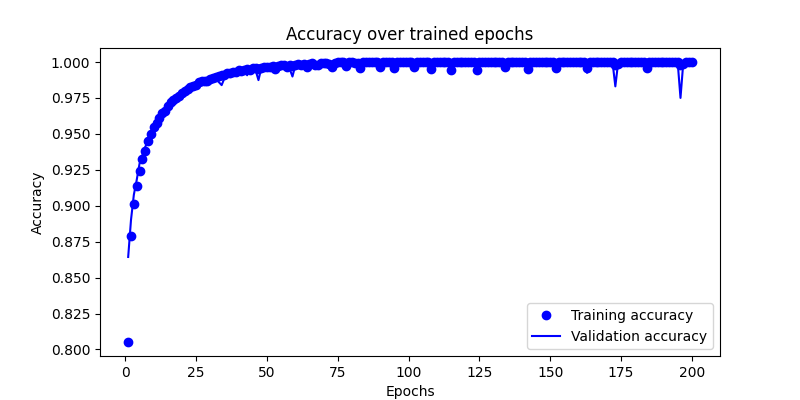

In [73]:
# plot the results 
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
num_of_epochs = range(1, len(loss_values)+1)

plt.figure(figsize = figure_sizes)
plt.plot(num_of_epochs, loss_values, 'bo', label='Training loss')
plt.plot(num_of_epochs, val_loss_values, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss values over trained epochs')


acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
plt.figure(figsize = figure_sizes)
plt.plot(num_of_epochs, acc_values, 'bo', label='Training accuracy')
plt.plot(num_of_epochs, val_acc_values, 'b', label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over trained epochs')

# Calc metrics for test data 

In [74]:
# predict Test data 
prediction_scores = model.predict(x_test)
prediction_labels = [0 if score <0.5 else 1 for score in prediction_scores]
prediction_labels = np.array(prediction_labels)

tnr, tpr, acc = calcTestAccAndRates(prediction_labels, y_test)

print("Metrics test data:")
print("TNR: ",np.round(tnr, 3))
print("TPR: ",np.round(tpr, 3)) 
print("Acc: ", np.round(acc, 3)) 


Metrics test data:
TNR:  1.0
TPR:  1.0
Acc:  1.0


# Single trial test for checking results

In [75]:
# single trial test 
# Predictions for positive class trial 
prediction_scores_single = model.predict(example_lrp_trial_norm)
prediction_labels_single = [0 if score <0.5 else 1 for score in prediction_scores_single]
prediction_labels_single = np.array(prediction_labels_single)
print("prediction positive class: ", prediction_labels_single)
print("")

# Predictions for negative class trial 
prediction_scores_single = model.predict(example_no_lrp_trial_norm)
prediction_labels_single = [0 if score <0.5 else 1 for score in prediction_scores_single]
prediction_labels_single = np.array(prediction_labels_single)
print("prediction negative class: ", prediction_labels_single)

prediction positive class:  [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1